In [1]:
%%capture captured_output
!pip install numpy==1.26
!pip install matplotlib==3.9.2
!pip install skillsnetwork

In [2]:
output_text = captured_output.stdout
lines = output_text.splitlines()
output_last_10_lines = '\n'.join(lines[-10:])
if "error" in output_last_10_lines.lower():
    print("Library installation failed!")
    print("--- Error Details ---")
    print(output_last_10_lines)
else:
    print("Library installation was successful, let's proceed ahead")

Library installation was successful, let's proceed ahead


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import skillsnetwork

from PIL import Image

In [4]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5vTzHBmQUaRNJQe5szCyKw/images-dataSAT.tar"

extraction_path = "."
await skillsnetwork.prepare(url = url, path = extraction_path, overwrite = True)

  0%|          | 0/6003 [00:00<?, ?it/s]

Saved to '.'


In [5]:
# Define directories
extract_dir = "."

base_dir = os.path.join(extract_dir, 'images_dataSAT')
dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')

In [6]:
non_agri = os.scandir(dir_non_agri)
# print first 5 file paths
for f_path in range(5):
    print(next(non_agri))


<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_25907.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_25984.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15608.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_3487.jpg'>
<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_14258.jpg'>


In [7]:
file_name = next(non_agri)
file_name

<DirEntry 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_25012.jpg'>

In [8]:
os.path.isfile(file_name)

True

In [9]:
image_name = str(file_name).split("'")[1]
image_name

'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_25012.jpg'

In [10]:
image_data = plt.imread(os.path.join(dir_non_agri, image_name))
image_data

array([[[ 86,  55,  63],
        [ 88,  57,  65],
        [104,  74,  82],
        ...,
        [ 95,  74,  79],
        [100,  79,  84],
        [ 76,  55,  60]],

       [[117,  86,  94],
        [109,  78,  86],
        [103,  73,  81],
        ...,
        [150, 129, 134],
        [153, 132, 137],
        [154, 133, 138]],

       [[159, 128, 136],
        [151, 120, 128],
        [135, 105, 113],
        ...,
        [215, 194, 199],
        [212, 191, 196],
        [240, 219, 224]],

       ...,

       [[ 29,  35,  21],
        [ 29,  35,  21],
        [ 31,  35,  21],
        ...,
        [127, 100, 105],
        [132, 105, 110],
        [123,  96, 101]],

       [[ 34,  40,  26],
        [ 33,  39,  25],
        [ 33,  37,  23],
        ...,
        [ 89,  62,  67],
        [ 95,  68,  73],
        [142, 115, 120]],

       [[ 25,  31,  17],
        [ 25,  31,  17],
        [ 26,  30,  16],
        ...,
        [112,  85,  90],
        [100,  73,  78],
        [ 94,  67,  72]]

In [11]:
## You can use this cell to type the code to answer the question.
print(image_data.shape)

(64, 64, 3)


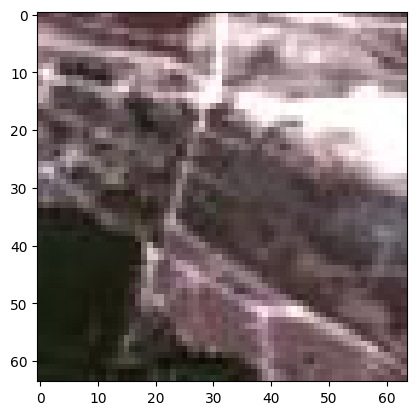

In [12]:
plt.imshow(image_data)

In [13]:
%%time

non_agri_images = []
for file_name in non_agri:
    if os.path.isfile(file_name):
        image_name = str(file_name).split("'")[1]
        image_data = plt.imread(os.path.join(dir_non_agri, image_name))
        non_agri_images.append(image_data)
    
non_agri_images = np.array(non_agri_images)

CPU times: user 164 ms, sys: 64.1 ms, total: 228 ms
Wall time: 238 ms


In [14]:
non_agri_images = os.listdir(dir_non_agri)
# print first 5 file paths
non_agri_images[:5]

['tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_25907.jpg',
 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UPE_20250427T170513.SAFE_25984.jpg',
 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_15608.jpg',
 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_3487.jpg',
 'tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQB_20250427T170513.SAFE_14258.jpg']

In [15]:
non_agri_images.sort()

# print first 5 file paths
non_agri_images[:5]

['tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 'tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [16]:
image_data = Image.open(os.path.join(dir_non_agri, non_agri_images[0]))

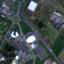

In [17]:
image_data

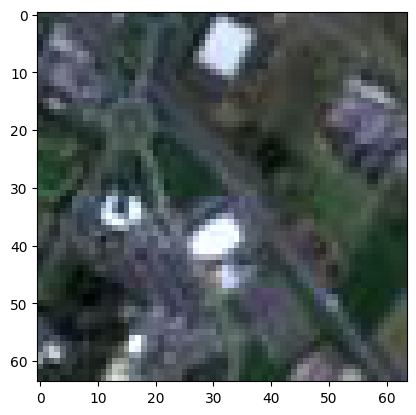

In [18]:
plt.imshow(image_data)

In [19]:
non_agri_images_paths = [os.path.join(dir_non_agri, image) for image in non_agri_images]
#print first five paths
non_agri_images_paths[:5]

['./images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg',
 './images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg',
 './images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg',
 './images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg',
 './images_dataSAT/class_0_non_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6248.jpg']

In [20]:
len(non_agri_images_paths)

3000

tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg


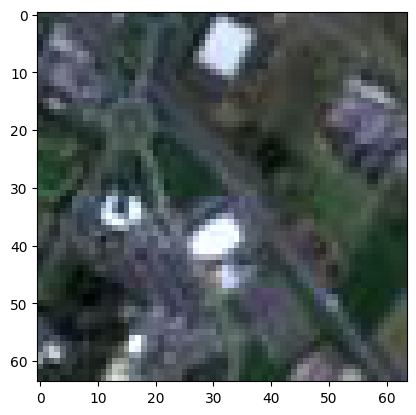

tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg


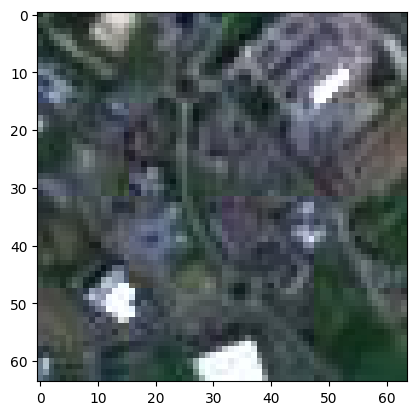

tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg


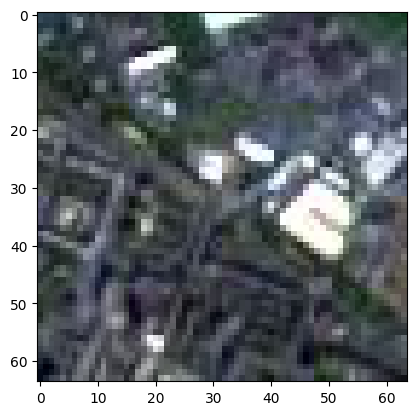

tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6247.jpg


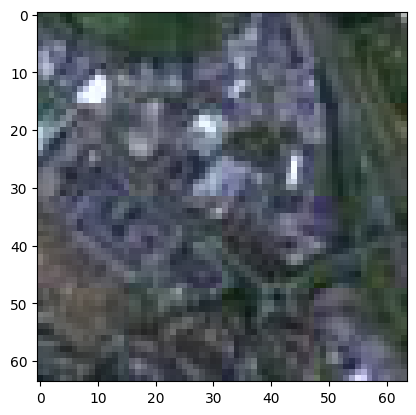

In [23]:
## You can use this cell to type the code to answer the question.
n_images = 4

for image_path in non_agri_images[:n_images]:
    print(image_path)
    img_data = Image.open(os.path.join(dir_non_agri, image_path))
    plt.imshow(img_data)
    plt.show()



In [24]:
## Type your answer here
agri_images_paths = []
for image in os.listdir(dir_agri):
    agri_images_paths.append(os.path.join(dir_agri, image))

agri_images_paths.sort()



In [25]:
## You can use this cell to type the code to answer the question.

print(len(agri_images_paths))



3000


./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5878.jpg


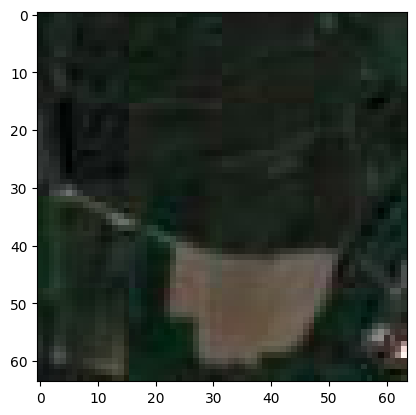

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5884.jpg


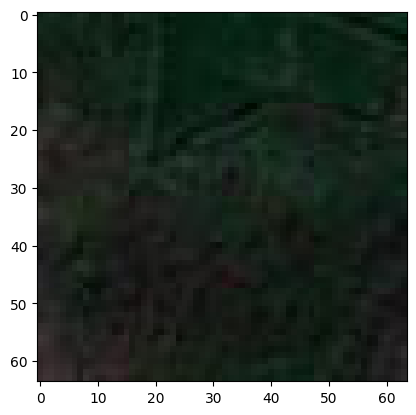

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6628.jpg


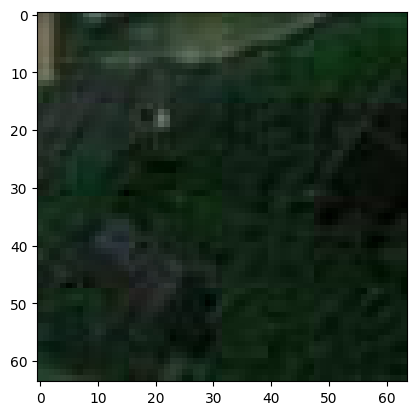

./images_dataSAT/class_1_agri/tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6629.jpg


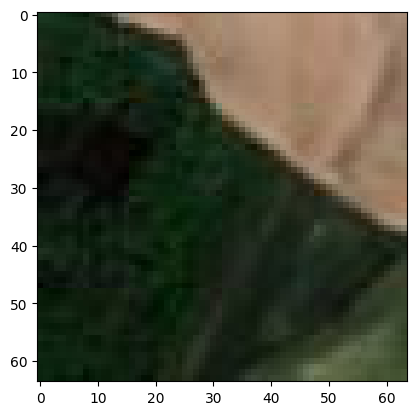

In [26]:
n_images = 4

for image_path in agri_images_paths[:n_images]:
    print(image_path)
    img_data = Image.open(image_path)
    plt.imshow(img_data)
    plt.show()
